<a href="https://colab.research.google.com/github/akshay-aiml/LangChain_LangGraph/blob/main/Simple_linear_workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
!pip install langchain-groq langgraph

In [41]:
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [42]:
from google.colab import userdata

api_key = userdata.get("GROQ_API_KEY")



In [49]:
llm = ChatGroq(model="llama-3.1-8b-instant",
               api_key=api_key,
               temperature=0.2)

In [50]:
# create State
from typing import TypedDict

class LLMState(TypedDict):
  Question: str
  Answer: str

In [51]:
def llm_qa(State:LLMState) -> LLMState:

#extracte question from state
  Question =  State["Question"]

#from a prompt
  prompt = f'Answer the following question in short {Question}'

# Ask the question to the llm
  Answer = llm.invoke(prompt).content

# Update the Asnser in the LLmstate
  State["Answer"] = Answer

  return State

In [52]:
# create our graph
graph = StateGraph(LLMState)

# add node
graph.add_node("llm_qa", llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

#compile
workflow = graph.compile()

In [53]:
initial_state = {'Question' : 'what make transformer more power full in AI domain ?'}

final_state = workflow.invoke(initial_state)

print(final_state['Answer'])

Several factors make transformers more powerful in the AI domain:

1. **Self-Attention Mechanism**: Allows the model to weigh the importance of different input elements relative to each other, enabling better contextual understanding.
2. **Parallelization**: Enables efficient computation of attention weights, making it scalable for large datasets.
3. **Multi-Head Attention**: Allows the model to learn multiple representations of the input data, improving its ability to capture complex relationships.
4. **Positional Encoding**: Enables the model to understand the order of input elements, which is crucial for sequential data like text or time series data.
5. **Efficient Computation**: Transformers use matrix multiplication, which is more efficient than recurrent neural networks (RNNs) for large datasets.

These factors combined make transformers a powerful tool for AI applications, particularly in natural language processing (NLP) and computer vision.


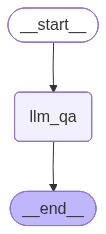

In [55]:
# draw the graph
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())